# Lysozyme cluster sizes and marker co-expression
Examine whether Lysozyme labels form isolated cells or extended connected regions, and whether larger regions contain cells co-expressing other markers. Compare the **aligned all-marker data before exclusivity** with the **same organoids after the existing exclusivity rules**. Mucin 2 and Glucagon are not restored. No model is trained or loaded and no curvature target is used.

One-hop clusters are connected components of the Lysozyme-positive induced graph. Two-hop clusters connect positive cells whose shortest path in the original graph is at most two edges, allowing any intermediate identity. Connectivity is transitive: cluster diameter can exceed two hops. Cluster size counts only Lysozyme-positive cells, including isolated cells as size one; intervening negative cells are never counted.

Defaults reproduce the paper cohort filters. Settings are exposed below so the whole cohort or individual experiments can also be inspected. The figures show cluster-weighted and cell-weighted distributions, experiment-specific distributions, and co-expression conditional on all-marker cluster size. These are descriptive checks: spatial clustering or co-expression alone cannot establish staining bleed or incorrect cell identity.

In [1]:
from pathlib import Path
import sys
import json
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p/'src/models/gnn.py').is_file())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0,str(PROJECT_ROOT))
from src.data.io import load_graph_dataset_from_dir
from src.data.metadata import load_aux_metadata_for_dir, attach_metadata_to_graphs, load_marker_names_from_dir
from src.data.filters import filter_graphs_by_metadata, filter_graphs_by_timepoints, filter_graphs_by_blacklist, load_graph_blacklist_from_dir, filter_graphs_by_sphericity
from src.data.marker_exclusivity import exclusive_markers, EXCLUSIVITY_RULES

## Settings
The same selected organoids and graph edges are used for both encodings. Filters only select organoids; they do not change labels or graph connectivity. Results are exported below a configuration-specific directory to separate different cohort selections.

In [2]:
# Dataset and shared cohort filters
DATASET = 'after_cleanup'  # Aligned marker dataset under training_data/.
MEASUREMENT_DATASETS = ['20250929', '20251201']  # None includes every experiment.
TIMEPOINTS = ['day4', 'day4p5', 'day4p5-more']  # None includes every timepoint.
APPLY_BLACKLIST = True  # Exclude the current dataset blacklist.
SPHERICITY_MAX = .94  # Keep Q < this cutoff, matching the paper filter; None disables it.

# Cluster definitions and display groups
MARKER = 'Lysozyme'  # Positive marker defining connected clusters.
MAX_HOPS = [1, 2]  # Maximum original-graph distance for linking two positive cells.
SIZE_EDGES = [0, 1, 2, 3, 4, 9, np.inf]  # Right-closed bins; exact sizes remain in exported tables.
SIZE_LABELS = ['1', '2', '3', '4', '5–9', '10+']  # Labels for SIZE_EDGES.

# Figure and table exports
OUTPUT_ROOT = PROJECT_ROOT/'results_experiments/data_quality/lysozyme_clusters'  # Dedicated diagnostics output.
FIGURE_FORMATS = ['png', 'pdf']  # Figures saved as well as displayed.

## Load and filter the shared cohort
Load the original binary features and apply the existing filters, printing their per-timepoint retention tables. Target preprocessing is unnecessary because this analysis uses only markers and graph adjacency. Marker-column consistency is checked for every retained organoid.

In [3]:
data_dir = PROJECT_ROOT/'training_data'/DATASET
graphs = load_graph_dataset_from_dir(str(data_dir), strict=True)
attach_metadata_to_graphs(graphs, load_aux_metadata_for_dir(str(data_dir)))
if MEASUREMENT_DATASETS is not None:
    graphs = filter_graphs_by_metadata(graphs, key='dataset', keep_values=set(MEASUREMENT_DATASETS), missing='drop', print_summary=True)
graphs = filter_graphs_by_timepoints(graphs, TIMEPOINTS, print_summary=True)
if APPLY_BLACKLIST:
    graphs = filter_graphs_by_blacklist(graphs, load_graph_blacklist_from_dir(data_dir), print_summary=True)
if SPHERICITY_MAX is not None:
    graphs = filter_graphs_by_sphericity(graphs, max_sphericity=SPHERICITY_MAX, print_summary=True)
if not graphs:
    raise ValueError('No organoids pass these filters.')
marker_names = load_marker_names_from_dir(str(data_dir))
if not marker_names or MARKER not in marker_names:
    raise ValueError(f'Missing marker names or {MARKER} in {data_dir}.')
for graph in graphs:
    names = json.loads((data_dir/f'{graph.organoid_str}_markers.json').read_text())
    assert names == marker_names and graph.x.shape[1] == len(marker_names)
marker_column = marker_names.index(MARKER)
other_markers = [name for name in marker_names if name != MARKER]
print(f'{len(graphs)} organoids; {sum(len(g.x) for g in graphs):,} cells. Markers: {marker_names}')
config = dict(dataset=DATASET, measurement_datasets=MEASUREMENT_DATASETS, timepoints=TIMEPOINTS,
    blacklist=APPLY_BLACKLIST, sphericity_max=SPHERICITY_MAX, marker=MARKER, max_hops=MAX_HOPS,
    size_edges=[v if np.isfinite(v) else 'inf' for v in SIZE_EDGES], size_labels=SIZE_LABELS,
    exclusivity_rules=EXCLUSIVITY_RULES)
config_id = hashlib.sha256(json.dumps(config, sort_keys=True).encode()).hexdigest()[:12]
OUTPUT_DIR = OUTPUT_ROOT/config_id
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR/'settings.json').write_text(json.dumps(config, indent=2))

def save_figure(fig, name):
    for extension in FIGURE_FORMATS:
        fig.savefig(OUTPUT_DIR/f'{name}.{extension}', dpi=180, bbox_inches='tight')
    plt.show()
    plt.close(fig)

Loaded 1500 graphs; skipped 0.


filter_graphs_by_metadata(key='dataset'): kept 1500 / 1500 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day3p5              290    290    1.000
20250929         day4                342    342    1.000
20250929         day4p5              113    113    1.000
20250929         day4p5-more         477    477    1.000
20251201         day4p5              278    278    1.000
filter_graphs_by_metadata(key='timepoint'): kept 1210 / 1500 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day3p5                0    290    0.000
20250929         day4                342    342    1.000
20250929         day4p5              113    113    1.000
20250929         day4p5-more         477    477    1.000
20251201         day4p5              278    278    1.000
filter_graphs_by_blacklist(n_keys=19): kept 1191 / 1210 graphs

## Find clusters and retain cell-level co-expression
Process one organoid at a time without making a second graph dataset. Short breadth-first searches establish links between positive cells; connected components of those links define clusters. Both encodings retain the original node indices for inspection. The all-marker cell table records each additional positive marker and the full co-expression signature.

Small synthetic checks distinguish two-hop linkage from a two-hop cluster radius and verify that negative bridge cells are not counted.

In [4]:
def positive_components(adjacency, positive, max_hops):
    """Components of positives linked by original-graph paths of at most max_hops."""
    if max_hops not in (1, 2):
        raise ValueError('This notebook supports one-hop and two-hop connectivity.')
    remaining = set(np.flatnonzero(positive).tolist())
    components = []
    while remaining:
        root = min(remaining)
        remaining.remove(root)
        component, pending = [root], [root]
        while pending:
            node = pending.pop()
            visited, frontier = {node}, {node}
            for _ in range(max_hops):
                frontier = {v for u in frontier for v in adjacency[u]} - visited
                visited.update(frontier)
            linked = remaining.intersection(visited)
            remaining.difference_update(linked)
            component.extend(sorted(linked))
            pending.extend(sorted(linked))
        components.append(sorted(component))
    return components

chain = [{1}, {0,2}, {1,3}, {2,4}, {3}, set()]
positive = np.array([True,False,True,False,True,True])
assert sorted(map(len,positive_components(chain,positive,1))) == [1,1,1,1]
assert sorted(map(len,positive_components(chain,positive,2))) == [1,3]
assert positive_components(chain,np.zeros(6,dtype=bool),2) == []
assert sorted(map(len,positive_components(chain,np.ones(6,dtype=bool),1))) == [1,5]

cluster_rows, cell_rows, organoid_rows = [], [], []
for graph in graphs:
    x = graph.x.cpu().numpy()
    assert np.isin(x,[0,1]).all()
    exclusive = exclusive_markers(x,marker_names)
    adjacency = [set() for _ in range(len(x))]
    for u,v in graph.edge_index.cpu().numpy().T:
        if u != v:
            adjacency[int(u)].add(int(v))
            adjacency[int(v)].add(int(u))
    info = dict(organoid=graph.organoid_str, dataset=str(graph.meta.get('dataset','unknown')),
                timepoint=str(graph.meta.get('timepoint','unknown')))
    organoid_rows.append(dict(**info, n_cells=len(x),
        all_marker_positive=int(x[:,marker_column].sum()), exclusive_positive=int(exclusive[:,marker_column].sum())))
    for encoding,features in [('all_markers',x),('exclusive',exclusive)]:
        for hops in MAX_HOPS:
            components = positive_components(adjacency,features[:,marker_column]>0,hops)
            assert sum(map(len,components)) == int(features[:,marker_column].sum())
            for cluster_id,members in enumerate(components):
                cluster_rows.append(dict(**info,encoding=encoding,hops=hops,cluster_id=cluster_id,size=len(members)))
                for node in members:
                    row = dict(**info,encoding=encoding,hops=hops,cluster_id=cluster_id,node=node,size=len(members))
                    if encoding == 'all_markers':
                        coexpressed = [name for name in other_markers if x[node,marker_names.index(name)]>0]
                        row.update({name:int(name in coexpressed) for name in other_markers})
                        row.update(n_other_markers=len(coexpressed),coexpression=' + '.join(coexpressed) or f'{MARKER} only')
                    cell_rows.append(row)
clusters = pd.DataFrame(cluster_rows)
cells = pd.DataFrame(cell_rows)
cohort = pd.DataFrame(organoid_rows)
if clusters.empty:
    raise ValueError(f'No {MARKER}-positive cells in this cohort.')
for table in [clusters,cells]:
    table['size_group'] = pd.cut(table['size'],SIZE_EDGES,labels=SIZE_LABELS,right=True)
assert cells.groupby(['encoding','hops']).size().groupby(level=0).nunique().eq(1).all()
for encoding in ['all_markers','exclusive']:
    a = cells[(cells.encoding==encoding)&(cells.hops==1)].set_index(['organoid','node'])
    b = cells[(cells.encoding==encoding)&(cells.hops==2)].set_index(['organoid','node'])
    if 1 in MAX_HOPS and 2 in MAX_HOPS:
        assert (b['size'].reindex(a.index)>=a['size']).all()
cohort.to_csv(OUTPUT_DIR/'cohort.csv',index=False)
clusters.to_csv(OUTPUT_DIR/'clusters.csv',index=False)
cells.to_csv(OUTPUT_DIR/'cluster_cells.csv.gz',index=False,compression='gzip')
display(cohort.groupby('dataset').agg(organoids=('organoid','size'),cells=('n_cells','sum'),
    all_marker_positive=('all_marker_positive','sum'),exclusive_positive=('exclusive_positive','sum')))
display(clusters.groupby(['encoding','hops']).agg(clusters=('size','size'),
    positive_cells=('size','sum'),median_size=('size','median'),largest_cluster=('size','max')))

,organoids,cells,all_marker_positive,exclusive_positive
dataset,,,,
20250929,712,329548,4826,4806
20251201,196,104206,957,946


clusters  positive_cells  median_size  largest_cluster
encoding    hops                                                        
all_markers 1         4888            5783          1.0               11
            2         3104            5783          1.0               25
exclusive   1         4868            5752          1.0               11
            2         3094            5752          1.0               25

## Figure 1 — Cluster size distributions
The upper row gives the fraction of **clusters** in each size bin; the lower row gives the fraction of **Lysozyme-positive cells** belonging to those clusters. Large clusters therefore receive more weight in the lower row. Counts include singletons, while organoids with no Lysozyme-positive cells remain in the cohort table but contribute no clusters. These are pooled distributions, not equal-organoid averages.

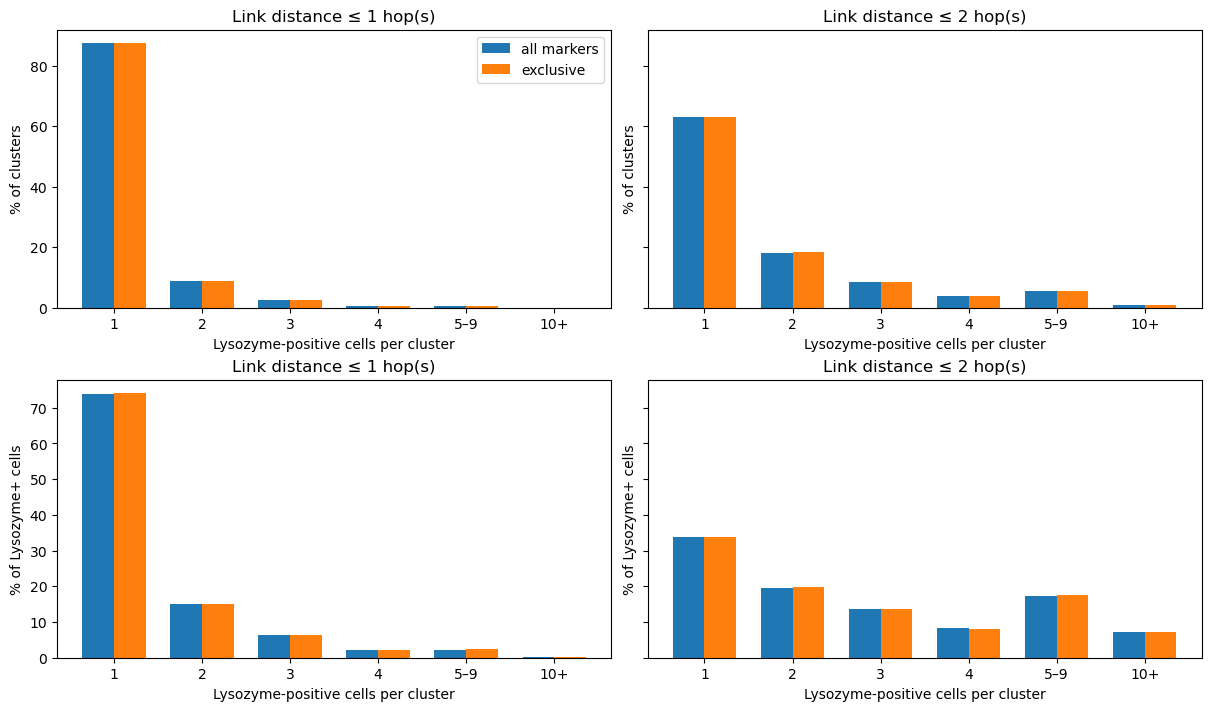

In [5]:
distribution_rows = []
for dataset in ['pooled',*sorted(cohort.dataset.unique())]:
    subset = clusters if dataset=='pooled' else clusters[clusters.dataset==dataset]
    for (encoding,hops),group in subset.groupby(['encoding','hops']):
        for label in SIZE_LABELS:
            selected = group[group.size_group==label]
            distribution_rows.append(dict(dataset=dataset,encoding=encoding,hops=hops,size_group=label,
                n_clusters=len(selected),n_cells=int(selected['size'].sum()),
                cluster_fraction=len(selected)/len(group),cell_fraction=selected['size'].sum()/group['size'].sum()))
distribution = pd.DataFrame(distribution_rows)
distribution.to_csv(OUTPUT_DIR/'size_distributions.csv',index=False)
colors = {'all_markers':'tab:blue','exclusive':'tab:orange'}
fig,axes = plt.subplots(2,len(MAX_HOPS),figsize=(6*len(MAX_HOPS),7),sharey='row',squeeze=False,layout='constrained')
y = np.arange(len(SIZE_LABELS))
for col,hops in enumerate(MAX_HOPS):
    for row,metric in enumerate(['cluster_fraction','cell_fraction']):
        ax = axes[row,col]
        for k,encoding in enumerate(colors):
            f = distribution[(distribution.dataset=='pooled')&(distribution.encoding==encoding)&(distribution.hops==hops)].set_index('size_group').reindex(SIZE_LABELS)
            ax.bar(y+(k-.5)*.36,100*f[metric],width=.36,color=colors[encoding],label=encoding.replace('_',' '))
        ax.set(title=f'Link distance ≤ {hops} hop(s)',xticks=y,xticklabels=SIZE_LABELS,
               xlabel=f'{MARKER}-positive cells per cluster',ylabel='% of clusters' if row==0 else f'% of {MARKER}+ cells')
axes[0,0].legend()
save_figure(fig,'cluster_size_distributions')

## Figure 2 — Compare the measurement datasets
Separate the two experiments to reveal whether pooled patterns are driven by one dataset. The y-axis is again the cluster-weighted fraction. Line style identifies the encoding and color identifies the measurement dataset.

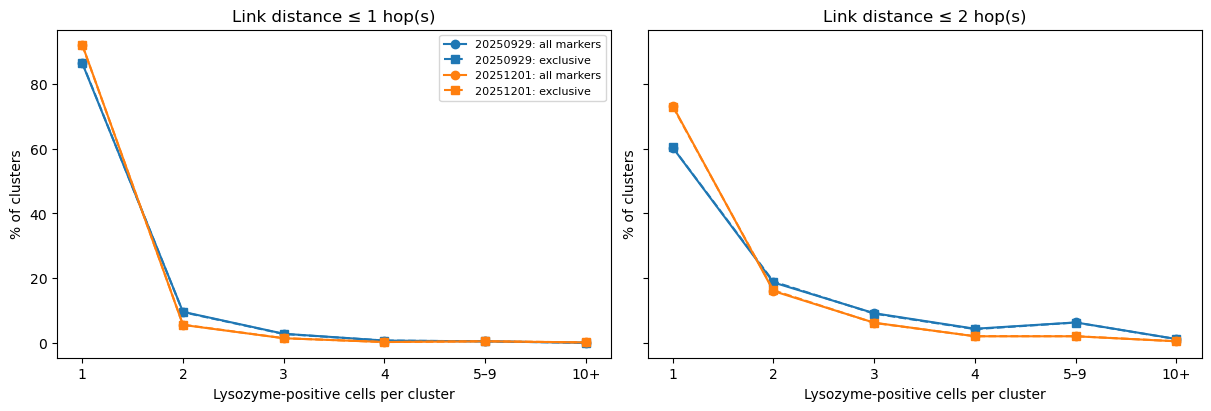

In [6]:
fig,axes = plt.subplots(1,len(MAX_HOPS),figsize=(6*len(MAX_HOPS),4),sharey=True,squeeze=False,layout='constrained')
for ax,hops in zip(axes.flat,MAX_HOPS):
    for k,dataset in enumerate(sorted(cohort.dataset.unique())):
        for encoding,style in [('all_markers','o-'),('exclusive','s--')]:
            f = distribution[(distribution.dataset==dataset)&(distribution.encoding==encoding)&(distribution.hops==hops)].set_index('size_group').reindex(SIZE_LABELS)
            ax.plot(y,100*f.cluster_fraction,style,color=f'C{k}',label=f'{dataset}: {encoding.replace("_"," ")}')
    ax.set(title=f'Link distance ≤ {hops} hop(s)',xticks=y,xticklabels=SIZE_LABELS,
           xlabel=f'{MARKER}-positive cells per cluster',ylabel='% of clusters')
axes[0,0].legend(fontsize=8)
save_figure(fig,'cluster_sizes_by_dataset')

## Figure 3 — Co-expressed markers within each cluster size
For the **all-marker encoding**, each heatmap entry is the percentage of Lysozyme-positive cells in that cluster-size bin also positive for the indicated marker. A cell may contribute to several rows, so the rows need not sum to 100%. Columns give their cell count to make sparse bins visible. Gray means no eligible cells, not zero expression. Co-expression is taken from the original feature vector, not from neighboring cells.

The export also includes separate measurement-dataset summaries to allow follow-up checks without recomputing clusters.

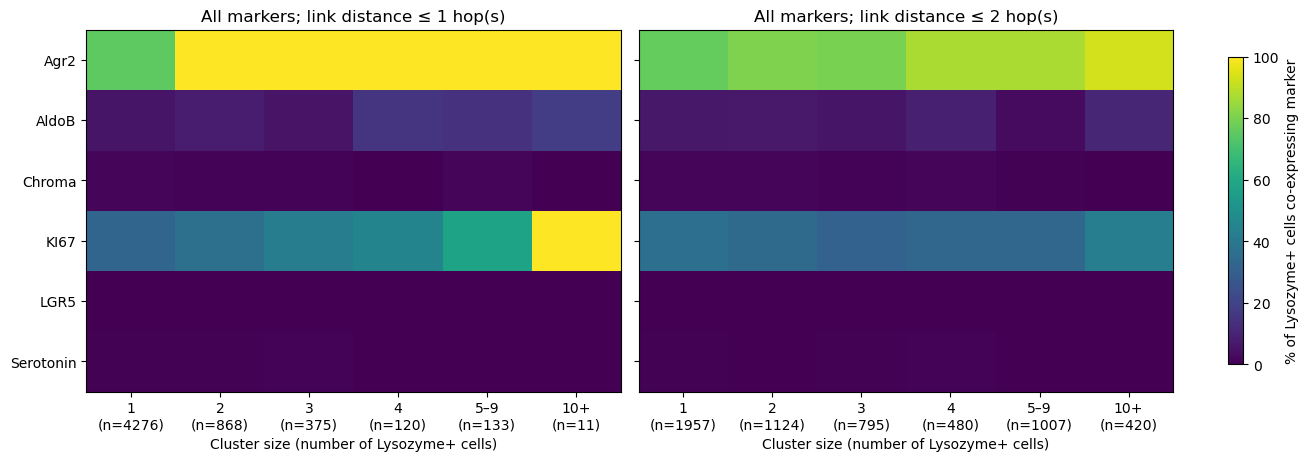

In [7]:
all_cells = cells[cells.encoding=='all_markers'].copy()
coexpression_rows = []
for dataset in ['pooled',*sorted(cohort.dataset.unique())]:
    frame = all_cells if dataset=='pooled' else all_cells[all_cells.dataset==dataset]
    for hops in MAX_HOPS:
        for label in SIZE_LABELS:
            group = frame[(frame.hops==hops)&(frame.size_group==label)]
            for marker in other_markers:
                coexpression_rows.append(dict(dataset=dataset,hops=hops,size_group=label,marker=marker,
                    n_cells=len(group),n_positive=int(group[marker].sum()),n_organoids=group.organoid.nunique(),
                    fraction=group[marker].mean() if len(group) else np.nan))
coexpression = pd.DataFrame(coexpression_rows)
coexpression.to_csv(OUTPUT_DIR/'coexpression_by_size.csv',index=False)
fig,axes = plt.subplots(1,len(MAX_HOPS),figsize=(6.5*len(MAX_HOPS),4.5),sharey=True,squeeze=False,layout='constrained')
cmap = plt.get_cmap('viridis').copy()
cmap.set_bad('lightgray')
for ax,hops in zip(axes.flat,MAX_HOPS):
    f = coexpression[(coexpression.dataset=='pooled')&(coexpression.hops==hops)]
    matrix = f.pivot(index='marker',columns='size_group',values='fraction').reindex(index=other_markers,columns=SIZE_LABELS)
    counts = f.groupby('size_group').n_cells.first().reindex(SIZE_LABELS)
    im = ax.imshow(100*matrix.to_numpy(),vmin=0,vmax=100,cmap=cmap,aspect='auto')
    ax.set(title=f'All markers; link distance ≤ {hops} hop(s)',yticks=np.arange(len(other_markers)),yticklabels=other_markers,
        xticks=y,xticklabels=[f'{label}\n(n={int(counts[label])})' for label in SIZE_LABELS],xlabel='Cluster size (number of Lysozyme+ cells)')
fig.colorbar(im,ax=list(axes.flat),label='% of Lysozyme+ cells co-expressing marker',shrink=.85)
save_figure(fig,'coexpression_by_cluster_size')

## Figure 4 — How many other markers does each Lysozyme-positive cell express?
These stacked proportions sum to 100% within each populated cluster-size bin. The zero category denotes Lysozyme-only cells. The full joint signatures (for example, Lysozyme + Agr2 + KI67) are exported separately, avoiding a crowded figure with every rare combination.

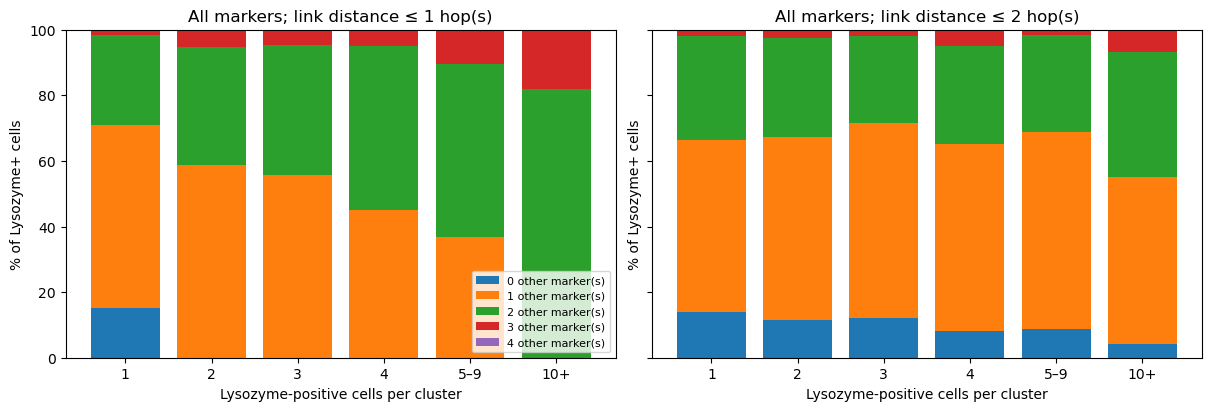

Figures and supporting tables: /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/data_quality/lysozyme_clusters/5bba97a12f39


In [8]:
multiplicity = all_cells.groupby(['hops','size_group','n_other_markers'],observed=True).size().rename('n_cells').reset_index()
multiplicity['fraction'] = multiplicity.n_cells/multiplicity.groupby(['hops','size_group'],observed=True).n_cells.transform('sum')
multiplicity.to_csv(OUTPUT_DIR/'coexpression_multiplicity.csv',index=False)
signatures = all_cells.groupby(['dataset','hops','size_group','coexpression'],observed=True).size().rename('n_cells').reset_index()
signatures['fraction'] = signatures.n_cells/signatures.groupby(['dataset','hops','size_group'],observed=True).n_cells.transform('sum')
signatures.to_csv(OUTPUT_DIR/'coexpression_signatures.csv',index=False)
fig,axes = plt.subplots(1,len(MAX_HOPS),figsize=(6*len(MAX_HOPS),4),sharey=True,squeeze=False,layout='constrained')
for ax,hops in zip(axes.flat,MAX_HOPS):
    bottom = np.zeros(len(SIZE_LABELS))
    for count in sorted(multiplicity.n_other_markers.unique()):
        f = multiplicity[(multiplicity.hops==hops)&(multiplicity.n_other_markers==count)].set_index('size_group').fraction.reindex(SIZE_LABELS,fill_value=0)
        ax.bar(y,100*f,bottom=bottom,label=f'{int(count)} other marker(s)',color=f'C{int(count)}')
        bottom += 100*f.to_numpy()
    ax.set(title=f'All markers; link distance ≤ {hops} hop(s)',xticks=y,xticklabels=SIZE_LABELS,
        xlabel=f'{MARKER}-positive cells per cluster',ylabel=f'% of {MARKER}+ cells',ylim=(0,100))
axes[0,0].legend(fontsize=8)
save_figure(fig,'coexpression_multiplicity')
print('Figures and supporting tables:',OUTPUT_DIR)

## Interpretation limits and follow-up
Larger clusters and increasing co-expression can identify candidates for inspecting staining, but can also reflect real Paneth-cell neighborhoods or co-expression. Two-hop clusters deliberately merge regions across negative cells and cannot be interpreted as contiguous patches of positive tissue. Exclusivity applies a deterministic labeling rule; it does not validate the original staining. Cluster distributions are pooled across selected cells/organoids and are descriptive, without independent-cell significance tests. Organoid, node, dataset, cluster ID, and exact size are saved in `cluster_cells.csv.gz` so suspicious large clusters can be traced back to their original graphs.